<a href="https://colab.research.google.com/github/SLIIT-Y4-S2-DL-ORG/Deep-Learning-Assignment/blob/main/MLP/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Layer Perceptron for Human Activity Recognition

This notebook implements, tunes and evaluates a Multi-Layer Perceptron
(MLP) for classifying six human activities using the common processed
UCI HAR dataset.

The notebook compares multiple MLP capacities using the training and
validation sets. The official test set remains unused during
architecture selection and is evaluated only after the final MLP
configuration has been selected.

The workflow includes:

- loading the shared processed dataset,
- reshaping the sensor windows for an MLP,
- defining candidate architectures,
- training candidates under common conditions,
- selecting the final architecture using validation results,
- evaluating the selected model on the test set,
- calculating multiple classification metrics,
- examining computational efficiency and model complexity, and
- saving results and the trained model.

## 1. Libraries and Reproducibility

TensorFlow/Keras is used to construct and train the neural network.
NumPy and Pandas are used for numerical processing and result storage,
while Matplotlib and Scikit-learn are used for visualization and model
evaluation.

Random seeds are fixed to improve reproducibility between experimental
runs.

In [ ]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
# Fix random seeds for reproducible model initialization and training
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "processed_Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_FILE = (
    PROJECT_ROOT
    / "processed_Data"
    / "har_processed.npz"
)

print("Processed dataset:", DATA_FILE)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {DATA_FILE}"
    )

print("Processed dataset found.")

Processed dataset: f:\research\Deep-Learning-Assignment\processed_Data\har_processed.npz
Processed dataset found.


## 2. Loading the Shared Processed Dataset

The MLP uses the common `har_processed.npz` file created by the
preprocessing pipeline.

This guarantees that the MLP receives exactly the same training,
validation and test partitions and normalization used by the CNN, LSTM
and GRU models.

In [3]:
data = np.load(DATA_FILE)

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

activity_names = data[
    "activity_names"
]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nLabels")
print("Train:", np.unique(y_train))
print("Validation:", np.unique(y_val))
print("Test:", np.unique(y_test))

print("\nActivities:")
print(activity_names)

Train: (5551, 128, 9)
Validation: (1801, 128, 9)
Test: (2947, 128, 9)

Labels
Train: [0 1 2 3 4 5]
Validation: [0 1 2 3 4 5]
Test: [0 1 2 3 4 5]

Activities:
['Walking' 'Walking Upstairs' 'Walking Downstairs' 'Sitting' 'Standing'
 'Laying']


## 3. Input Validation

Before constructing the model, the loaded arrays are checked to verify
their dimensions and class labels.

These checks help identify accidental changes to the processed dataset
before model training begins.

In [4]:
assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1:] == (128, 9)
assert X_val.shape[1:] == (128, 9)
assert X_test.shape[1:] == (128, 9)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert np.array_equal(
    np.unique(y_train),
    np.arange(6)
), "Training labels must be 0-5"

assert np.array_equal(
    np.unique(y_val),
    np.arange(6)
), "Validation labels must be 0-5"

assert np.array_equal(
    np.unique(y_test),
    np.arange(6)
), "Test labels must be 0-5"

print("All dataset checks passed.")

All dataset checks passed.


## 4. MLP-Specific Input Transformation

The shared sensor data has shape `(samples, 128, 9)`, where 128
represents time steps and nine represents sensor channels.

A Multi-Layer Perceptron accepts a one-dimensional feature vector for
each observation. Therefore, every sensor window is flattened:

`128 × 9 = 1,152 features`

The training, validation and test partitions are reshaped independently
without changing their sample membership.

This flattening operation is specific to the MLP. CNN, LSTM and GRU
models retain the original temporal representation.

In [ ]:
# Flatten time steps and sensor channels into one feature vector per sample
X_train_mlp = X_train.reshape(
    X_train.shape[0],
    -1
)
# Flatten time steps and sensor channels into one feature vector per sample
X_val_mlp = X_val.reshape(
    X_val.shape[0],
    -1
)
# Flatten time steps and sensor channels into one feature vector per sample
X_test_mlp = X_test.reshape(
    X_test.shape[0],
    -1
)

print("MLP train:", X_train_mlp.shape)
print("MLP validation:", X_val_mlp.shape)
print("MLP test:", X_test_mlp.shape)

print("Original input:", X_train.shape)
print("MLP input:", X_train_mlp.shape)

assert X_train_mlp.shape[1] == 1152

MLP train: (5551, 1152)
MLP validation: (1801, 1152)
MLP test: (2947, 1152)
Original input: (5551, 128, 9)
MLP input: (5551, 1152)


## 5. Candidate MLP Architectures

Three MLP configurations are evaluated to investigate the effect of
network depth and width on classification performance and computational
cost.

The candidates are:

- **MLP_A_Small:** 128 → 64 hidden units
- **MLP_B_Medium:** 256 → 128 → 64 hidden units
- **MLP_C_Large:** 512 → 256 → 128 → 64 hidden units

All candidates use the same input data, optimizer, loss function,
training procedure and evaluation process. This allows model capacity
to be compared under controlled conditions.

In [6]:
MLP_CANDIDATES = {
    "MLP_A_Small": [128, 64],
    "MLP_B_Medium": [256, 128, 64],
    "MLP_C_Large": [512, 256, 128, 64]
}

MLP_CANDIDATES

{'MLP_A_Small': [128, 64],
 'MLP_B_Medium': [256, 128, 64],
 'MLP_C_Large': [512, 256, 128, 64]}

## 6. MLP Architecture Construction

A reusable model-building function is used so that each candidate is
constructed using the same architectural rules.

Each hidden layer contains a fully connected Dense layer with ReLU
activation, followed by Batch Normalization and Dropout.

ReLU introduces non-linearity, Batch Normalization helps stabilize
intermediate activations, and Dropout provides regularization.

The output layer contains six Softmax neurons corresponding to the six
activity classes.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)
# Define the MLP input vector containing 1,152 flattened features
def build_mlp(hidden_layers):
    model = Sequential()

    # Input: flattened 128 × 9 sensor window
    model.add(
        Input(
            shape=(X_train_mlp.shape[1],)
        )
    )
# Add each candidate's hidden Dense layer
# ReLU provides nonlinear feature learning
# Normalize intermediate activations to support stable training
    for units in hidden_layers:
        model.add(
            Dense(
                units,
                activation="relu"
            )
        )

        model.add(
            BatchNormalization()
        )
# Randomly deactivate 30% of units during training for regularization
        model.add(
            Dropout(0.30)
        )
# Six-class Softmax output
    # 6 HAR activity classes
    model.add(
        Dense(
            6,
            activation="softmax"
        )
    )

    return model

## 7. Model Compilation

All MLP candidates are compiled using the same optimization
configuration to maintain a fair comparison.

The Adam optimizer is used with a learning rate of 0.001.
Sparse categorical cross-entropy is used because the target activities
are represented as integer class labels from 0 to 5.

Accuracy is monitored during training, while additional metrics are
calculated during final evaluation.

In [ ]:
from tensorflow.keras.optimizers import Adam
# Adam performs adaptive gradient-based optimization
def compile_mlp(model):
    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
# Sparse categorical cross-entropy is appropriate for integer multiclass labels
        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [9]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

## 8. Training Control and Regularization

Two callbacks are used during candidate training.

**Early Stopping** monitors validation loss and terminates training when
no improvement is observed for ten consecutive epochs. The weights from
the best validation-loss epoch are restored.

**ReduceLROnPlateau** reduces the learning rate when validation loss
fails to improve for five epochs. This allows the optimizer to make
smaller parameter updates as training approaches a plateau.

Together, these mechanisms reduce unnecessary computation and help
control overfitting and unstable convergence.

## 9. Training the MLP Candidates

Each candidate model is trained independently using identical
experimental conditions.

Before every candidate is created, the previous TensorFlow session is
cleared and the random seeds are reset. This reduces unwanted influence
from the previously trained candidate.

Training uses:

- a maximum of 100 epochs,
- batch size 64,
- the common training partition, and
- the common validation partition.

Training duration, number of epochs and model parameter count are
recorded in addition to validation performance.

In [10]:
SEED = 42

experiment_results = []
experiment_histories = {}
trained_models = {}

for model_name, hidden_layers in MLP_CANDIDATES.items():

    print("\n" + "=" * 60)
    print(f"Training {model_name}")
    print("Architecture:", hidden_layers)
    print("=" * 60)

    # Clear previous TensorFlow model state
    tf.keras.backend.clear_session()

    # Reset random seeds
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # Build new model
    model = build_mlp(
        hidden_layers
    )

    model = compile_mlp(
        model
    )

    # IMPORTANT:
    # create NEW callbacks for each model
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    # Record training time
    start_time = time.time()

    history = model.fit(
        X_train_mlp,
        y_train,

        validation_data=(
            X_val_mlp,
            y_val
        ),

        epochs=100,
        batch_size=64,

        callbacks=[
            early_stopping,
            reduce_lr
        ],

        verbose=1
    )

    training_time = (
        time.time() - start_time
    )

   # Evaluate the restored best model on validation data
    best_val_loss, best_val_accuracy = model.evaluate(
    X_val_mlp,
    y_val,
    verbose=0
    )

    epochs_trained = len(
        history.history["loss"]
    )

    parameters = model.count_params()

    # Save experiment information
    experiment_results.append({
        "Model": model_name,
        "Architecture": str(hidden_layers),
        "Best Validation Accuracy":
            best_val_accuracy,
        "Best Validation Loss":
            best_val_loss,
        "Parameters":
            parameters,
        "Training Time (s)":
            training_time,
        "Epochs Trained":
            epochs_trained
    })

    # Keep histories for plotting later
    experiment_histories[
        model_name
    ] = history.history

    # Keep trained model in memory
    trained_models[
        model_name
    ] = model


Training MLP_A_Small
Architecture: [128, 64]



Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6992 - loss: 0.8383 - val_accuracy: 0.8928 - val_loss: 0.4017 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8407 - loss: 0.4281 - val_accuracy: 0.9534 - val_loss: 0.1984 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8782 - loss: 0.3215 - val_accuracy: 0.9550 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8870 - loss: 0.2881 - val_accuracy: 0.9634 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9056 - loss: 0.2396 - val_accuracy: 0.9595 - val_loss: 0.1475 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9139 - loss: 0.2195 - val_accuracy: 0.9628 - val_loss: 0.1312 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9191 - loss: 0.1997 - va

## 10. Candidate Model Comparison

The candidate results are summarized using validation performance,
validation loss, parameter count, training time and the number of
epochs completed.

Model selection considers both predictive performance and computational
complexity. The largest model is therefore not automatically preferred
unless the additional complexity provides a meaningful improvement.

In [11]:
results_df = pd.DataFrame(
    experiment_results
)

results_df

,Model,Architecture,Best Validation Accuracy,Best Validation Loss,Parameters,Training Time (s),Epochs Trained
0,MLP_A_Small,"[128, 64]",0.965019,0.102926,156998,32.427805,30
1,MLP_B_Medium,"[256, 128, 64]",0.964464,0.123089,338502,28.130117,21
2,MLP_C_Large,"[512, 256, 128, 64]",0.961133,0.123319,767046,38.548250,15


In [12]:
results_df.sort_values(
    by="Best Validation Accuracy",
    ascending=False
)

,Model,Architecture,Best Validation Accuracy,Best Validation Loss,Parameters,Training Time (s),Epochs Trained
0,MLP_A_Small,"[128, 64]",0.965019,0.102926,156998,32.427805,30
1,MLP_B_Medium,"[256, 128, 64]",0.964464,0.123089,338502,28.130117,21
2,MLP_C_Large,"[512, 256, 128, 64]",0.961133,0.123319,767046,38.548250,15


### Validation Accuracy Across Candidates

Validation accuracy is plotted across epochs for all three candidates.

This visualization is used to compare convergence speed, peak
performance and stability between architectures.

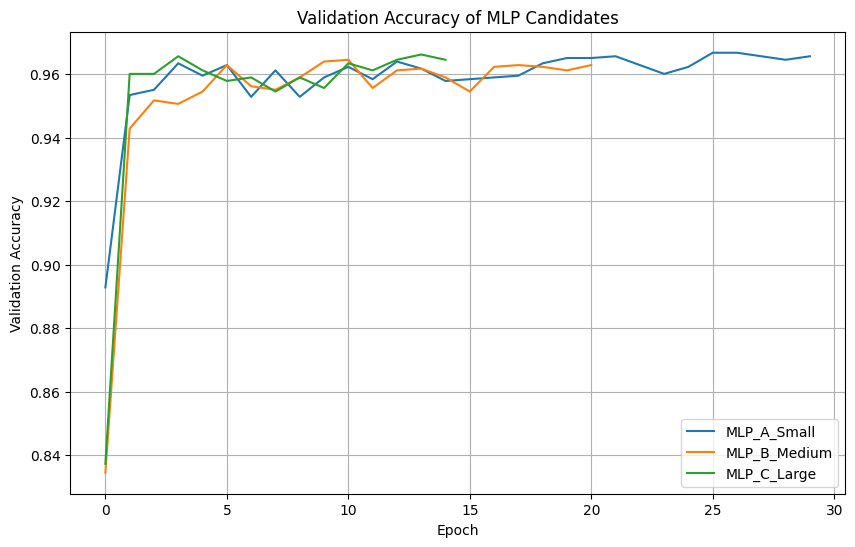

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():

    plt.plot(
        history["val_accuracy"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title(
    "Validation Accuracy of MLP Candidates"
)
plt.legend()
plt.grid()

plt.show()

### Validation Loss Across Candidates

Validation loss is compared across the candidate models.

Loss provides additional information beyond accuracy and is also the
quantity monitored by the Early Stopping and ReduceLROnPlateau
callbacks.

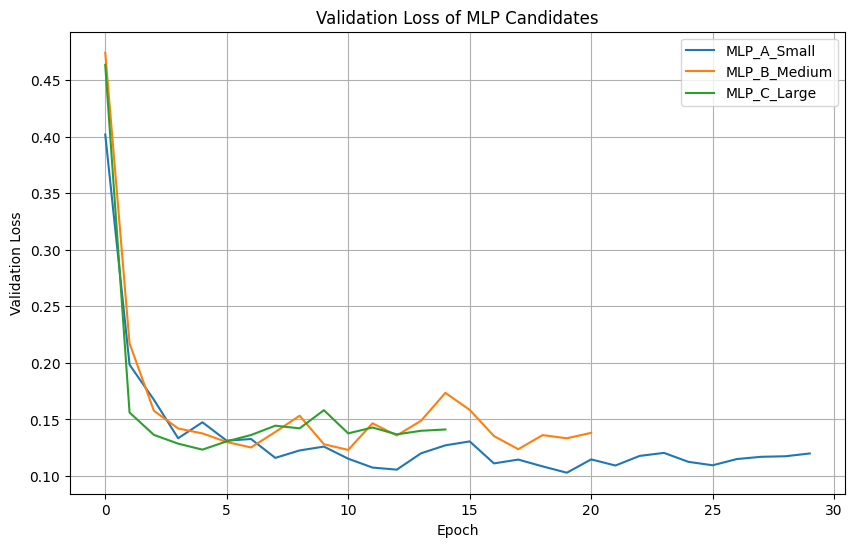

In [14]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():

    plt.plot(
        history["val_loss"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss of MLP Candidates"
)
plt.legend()
plt.grid()

plt.show()

## 11. Final MLP Selection

Following the validation-stage comparison, `MLP_A_Small` is selected as
the final MLP configuration.

The selection is performed before accessing the test-set performance.
This preserves the test set as an independent final evaluation dataset.

The selected model's training history, parameter count, training time
and number of epochs are retained for subsequent analysis.

In [15]:
FINAL_MODEL_NAME = "MLP_A_Small"

final_model = trained_models[
    FINAL_MODEL_NAME
]

final_history = experiment_histories[
    FINAL_MODEL_NAME
]

selected_result = results_df.loc[
    results_df["Model"] == FINAL_MODEL_NAME
].iloc[0]

final_training_time = float(
    selected_result["Training Time (s)"]
)

final_epochs_trained = int(
    selected_result["Epochs Trained"]
)

total_parameters = final_model.count_params()

print("Selected model:", FINAL_MODEL_NAME)
print("Parameters:", total_parameters)
print(
    f"Training time: "
    f"{final_training_time:.2f} seconds"
)
print(
    "Epochs trained:",
    final_epochs_trained
)

Selected model: MLP_A_Small
Parameters: 156998
Training time: 32.43 seconds
Epochs trained: 30


## 12. Training Behaviour of the Selected MLP

### Accuracy Curves

Training and validation accuracy are plotted over the completed epochs.

The relationship between these curves is used to examine convergence
and generalization. A growing difference between training and
validation performance may indicate overfitting.

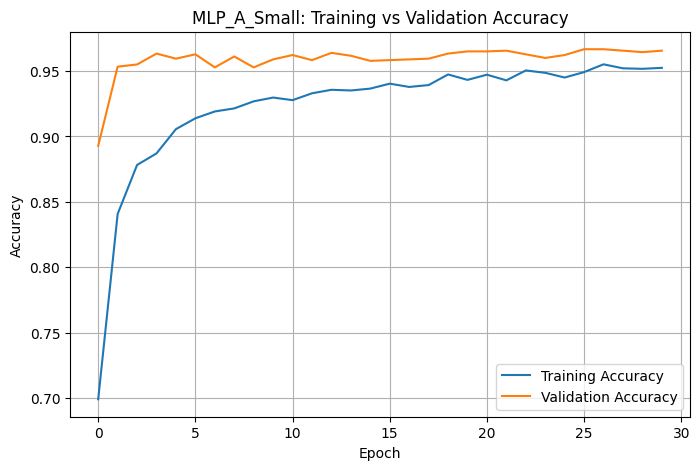

In [16]:
final_history = experiment_histories[
    FINAL_MODEL_NAME
]

plt.figure(figsize=(8, 5))

plt.plot(
    final_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    f"{FINAL_MODEL_NAME}: Training vs Validation Accuracy"
)

plt.legend()
plt.grid()
plt.show()

### Loss Curves

Training and validation loss are plotted to examine optimization
behaviour.

Validation loss is particularly important because it is used by both
Early Stopping and learning-rate reduction. Divergence between training
and validation loss may provide evidence of overfitting.

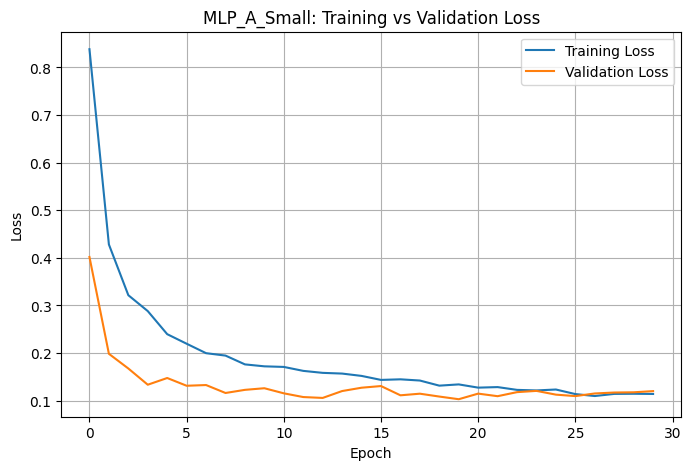

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    f"{FINAL_MODEL_NAME}: Training vs Validation Loss"
)

plt.legend()
plt.grid()
plt.show()

## 13. Final Evaluation on the Unseen Test Set

The official test dataset is accessed only after the final MLP
configuration has been selected using training and validation data.

No architecture or hyperparameter changes should be made based on these
test results.

The selected model is evaluated to obtain test loss and test accuracy.
Class probabilities are then generated for the calculation of
additional evaluation metrics.

### Inference Efficiency

Prediction time is measured on the complete test set.

Both total inference time and average inference time per sample are
reported as indicators of computational efficiency. These measurements
will later support comparison with CNN, LSTM and GRU architectures.

In [18]:
# Final evaluation on the unseen test set

test_loss, test_accuracy = final_model.evaluate(
    X_test_mlp,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


# Measure inference time and generate predictions

start_inference = time.time()

y_probability = final_model.predict(
    X_test_mlp,
    verbose=0
)

inference_time = (
    time.time() - start_inference
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print(
    f"Inference time: "
    f"{inference_time:.4f} seconds"
)

print(
    f"Average inference time per sample: "
    f"{inference_time / len(X_test_mlp):.6f} seconds"
)

Test Loss: 0.2764
Test Accuracy: 0.9077
Inference time: 0.5644 seconds
Average inference time per sample: 0.000192 seconds


## 14. Detailed Classification Performance

A classification report is generated to examine precision, recall and
F1-score independently for each activity.

This analysis is important because overall accuracy alone can hide poor
performance on individual classes.
- **Precision** indicates how many predictions assigned to an activity
  were correct.

- **Recall** indicates how many true examples of an activity were
  correctly identified.

- **F1-score** combines precision and recall into a single measure.

In [19]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=activity_names,
        digits=4
    )
)

                    precision    recall  f1-score   support

           Walking     0.9914    0.9274    0.9583       496
  Walking Upstairs     0.9191    0.9406    0.9297       471
Walking Downstairs     0.8820    0.9786    0.9278       420
           Sitting     0.8158    0.7760    0.7954       491
          Standing     0.8374    0.8327    0.8351       532
            Laying     0.9963    1.0000    0.9981       537

          accuracy                         0.9077      2947
         macro avg     0.9070    0.9092    0.9074      2947
      weighted avg     0.9081    0.9077    0.9073      2947



## 15. Overall Evaluation Metrics

Several aggregate metrics are calculated to provide a more complete
assessment of model performance.

**Accuracy** measures the overall proportion of correct classifications.

**Weighted Precision, Recall and F1-score** account for the number of
samples belonging to each activity.

**Macro F1-score** calculates the F1-score independently for every
activity and gives all six classes equal importance regardless of their
frequency.

Reporting both macro and weighted metrics helps determine whether
overall performance is consistent across the activity classes.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1:        {f1_weighted:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")

Accuracy:           0.9077
Weighted Precision: 0.9081
Weighted Recall:    0.9077
Weighted F1:        0.9073
Macro F1:           0.9074


## 16. Confusion Matrix Analysis

The confusion matrix shows the number of correct and incorrect
predictions for every pair of actual and predicted activities.

Values along the main diagonal represent correct predictions, while
off-diagonal values identify specific activity pairs that the MLP finds
difficult to distinguish.

This visualization is particularly useful for analysing class-specific
weaknesses that may not be apparent from overall accuracy.

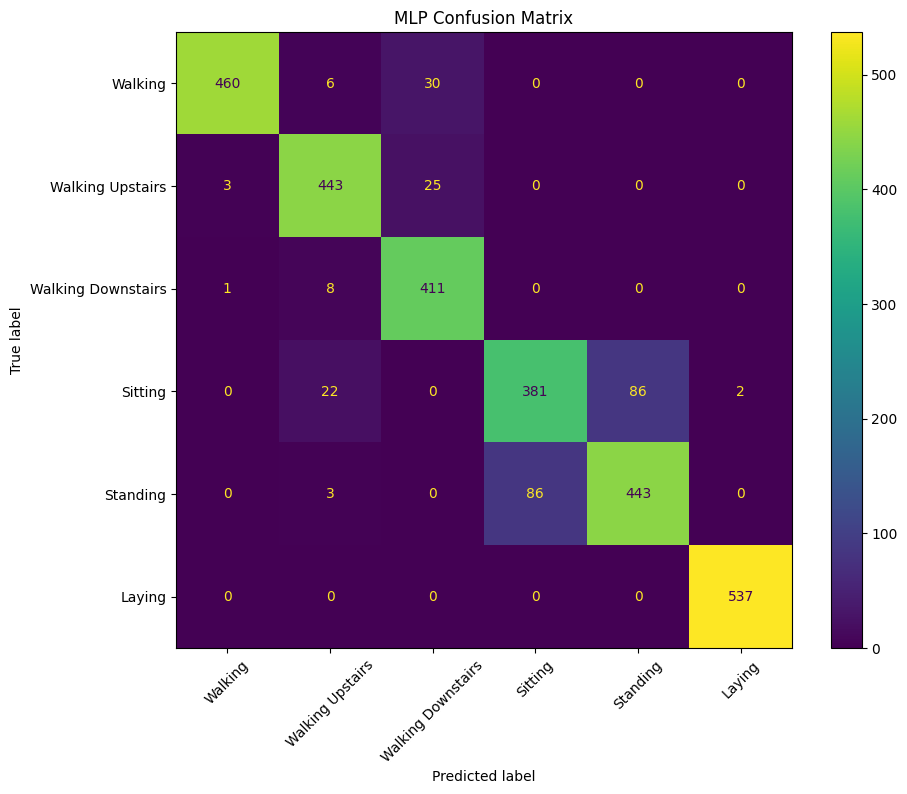

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activity_names
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "MLP Confusion Matrix"
)

plt.show()

## 18. Saving Experimental Results

The final experimental outputs are saved to the shared `Results`
directory to support reproducibility and the later comparison with the
CNN, LSTM and GRU architectures.

In [ ]:
# Save the selected MLP's final evaluation metrics
RESULTS_DIR = (
    PROJECT_ROOT
    / "Results"
    / "MLP"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [23]:
results = pd.DataFrame([
    {
        "Model": FINAL_MODEL_NAME,
        "Architecture": str(
            MLP_CANDIDATES[FINAL_MODEL_NAME]
        ),
        "Accuracy": accuracy,
        "Precision_weighted": precision_weighted,
        "Recall_weighted": recall_weighted,
        "F1_weighted": f1_weighted,
        "F1_macro": f1_macro,
        "Test_loss": test_loss,
        "Parameters": total_parameters,
        "Training_time_seconds": final_training_time,
        "Inference_time_seconds": inference_time,
        "Epochs_trained": final_epochs_trained
    }
])

results.to_csv(
    RESULTS_DIR / "mlp_results.csv",
    index=False
)

results

,Model,Architecture,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro,Test_loss,Parameters,Training_time_seconds,Inference_time_seconds,Epochs_trained
0,MLP_A_Small,"[128, 64]",0.907703,0.908091,0.907703,0.907255,0.907401,0.276403,156998,32.427805,0.564369,30


In [24]:
results_df.to_csv(
    RESULTS_DIR
    / "mlp_candidate_comparison.csv",
    index=False
)

print("Candidate comparison saved.")

Candidate comparison saved.


In [25]:
history_df = pd.DataFrame(
    final_history
)

history_df.to_csv(
    RESULTS_DIR
    / "mlp_training_history.csv",
    index=False
)

print("Final model training history saved.")

Final model training history saved.


In [26]:
final_model.save(
    RESULTS_DIR / "mlp_final.keras"
)

print("Final MLP model saved.")

Final MLP model saved.


## 19. MLP Experiment Summary

This notebook evaluated three MLP architectures under the same
training and validation conditions.

The final architecture was selected using validation-stage evidence
before the official test set was evaluated. Final performance was
measured using multiple classification metrics, a confusion matrix,
ROC-AUC, model complexity, training duration and inference time.

The MLP provides a useful fully connected reference model for the final
comparison with the 1D CNN, LSTM and GRU architectures.

A key limitation of the MLP is that the `(128, 9)` sensor window must
be flattened into 1,152 features. Therefore, temporal ordering is not
explicitly represented by the architecture, unlike the sequence-aware
models considered elsewhere in the project.